Hotel Reviews




In [8]:
import pandas as pd
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, "tripadvisor_hotel_reviews.csv"))

Using Colab cache for faster access to the 'trip-advisor-hotel-reviews' dataset.
Path to dataset files: /kaggle/input/trip-advisor-hotel-reviews


In [9]:
print(df.head())
print(df.info())
print(df.shape)

                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None
(20491, 2)


In [10]:
pip install nltk textblob wordcloud seaborn scikit-learn

In [11]:
import pandas as pd
import numpy as np
import re

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [12]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(clean_text)

df.head()

,Review,Rating,Clean_Review
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...


In [13]:
def sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(sentiment)

df.head()

,Review,Rating,Clean_Review,Sentiment
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,Positive
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,Negative
2,nice rooms not 4* experience hotel monaco seat...,3,nice room experience hotel monaco seattle good...,Neutral
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,Positive
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,Positive


In [14]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64


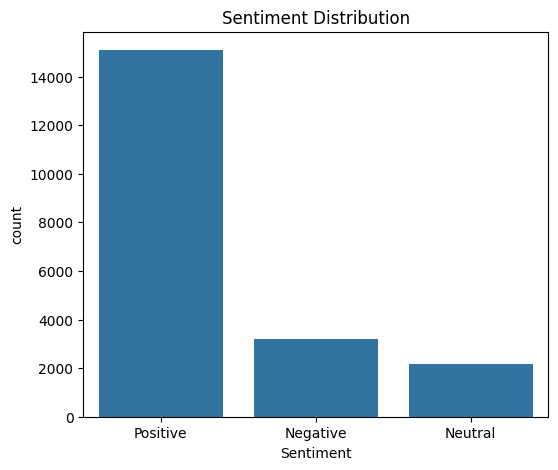

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Sentiment")

plt.title("Sentiment Distribution")

plt.show()

In [16]:
issues = {

    "Room":[
        "room","bed","bathroom","ac","air","window","suite"
    ],

    "Staff":[
        "staff","manager","service","reception","employee"
    ],

    "Food":[
        "food","breakfast","restaurant","meal","dinner","lunch"
    ],

    "Cleanliness":[
        "dirty","clean","dust","smell","stain","wash"
    ],

    "Amenities":[
        "wifi","pool","parking","gym","spa","internet"
    ]

}

In [17]:
def detect_issue(review):

    review = review.lower()

    found = []

    for category, keywords in issues.items():

        for word in keywords:

            if word in review:

                found.append(category)

                break

    if len(found)==0:

        return "Other"

    return ",".join(found)

df["Issue"] = df["Clean_Review"].apply(detect_issue)

df.head()

,Review,Rating,Clean_Review,Sentiment,Issue
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,Positive,"Room,Cleanliness,Amenities"
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,Negative,"Room,Staff,Food,Cleanliness"
2,nice rooms not 4* experience hotel monaco seat...,3,nice room experience hotel monaco seattle good...,Neutral,"Room,Staff,Amenities"
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,Positive,"Room,Staff,Cleanliness,Amenities"
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,Positive,"Room,Staff,Amenities"


In [18]:
print(df["Issue"].value_counts())

Issue
Room,Staff,Food,Cleanliness,Amenities    3331
Room,Staff,Food,Amenities                2589
Room,Staff,Food                          2498
Room,Staff,Food,Cleanliness              2317
Room,Staff                               1654
Room,Staff,Cleanliness                   1221
Room,Staff,Amenities                      860
Room,Staff,Cleanliness,Amenities          773
Room                                      763
Room,Food                                 756
Room,Food,Amenities                       669
Room,Food,Cleanliness                     650
Room,Food,Cleanliness,Amenities           650
Room,Cleanliness                          493
Room,Amenities                            361
Room,Cleanliness,Amenities                274
Staff                                     148
Other                                     109
Staff,Food                                108
Staff,Cleanliness                          46
Food                                       40
Staff,Food,Cleanliness      

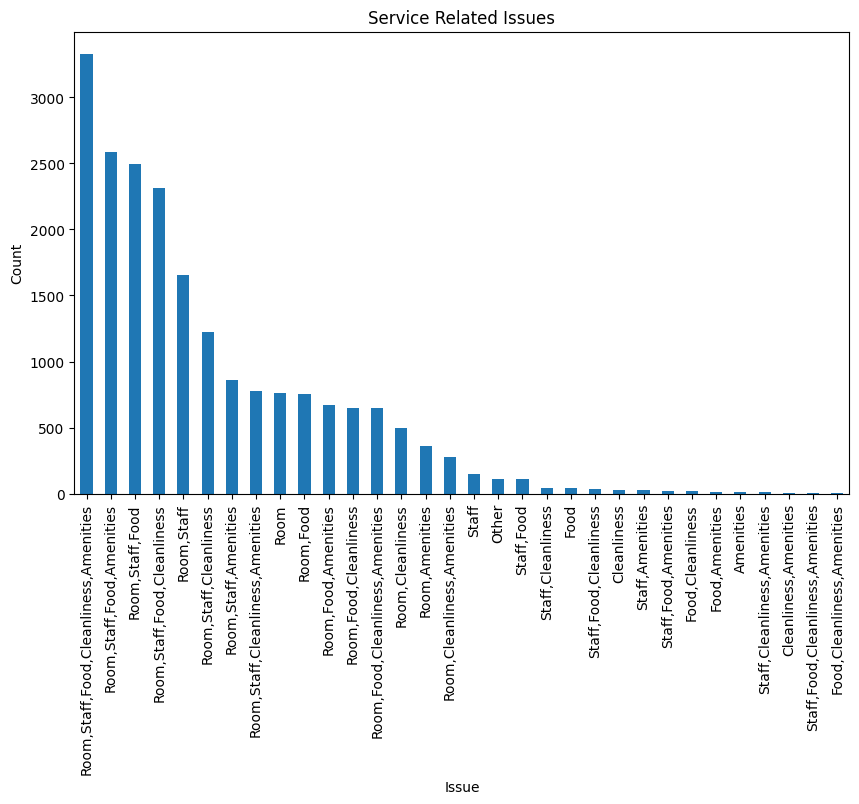

In [19]:
plt.figure(figsize=(10,6))

df["Issue"].value_counts().plot(kind="bar")

plt.title("Service Related Issues")

plt.ylabel("Count")

plt.show()

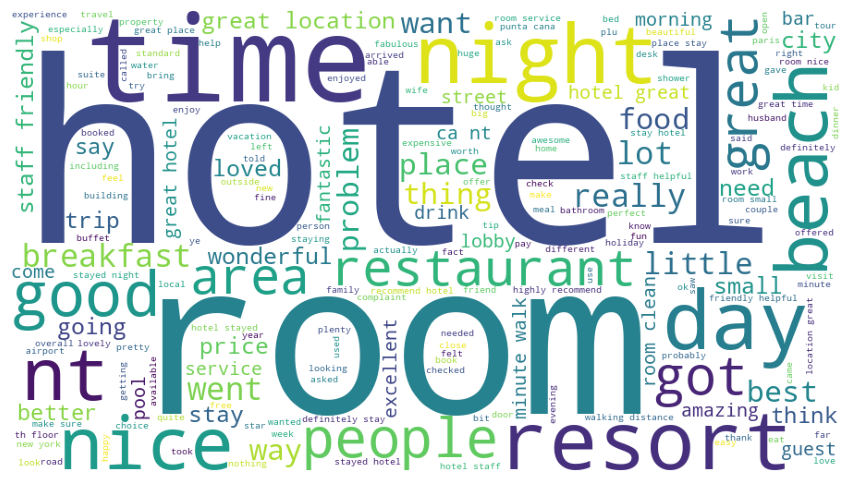

In [20]:
from wordcloud import WordCloud

positive_text = " ".join(df[df["Sentiment"]=="Positive"]["Clean_Review"])

wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.show()

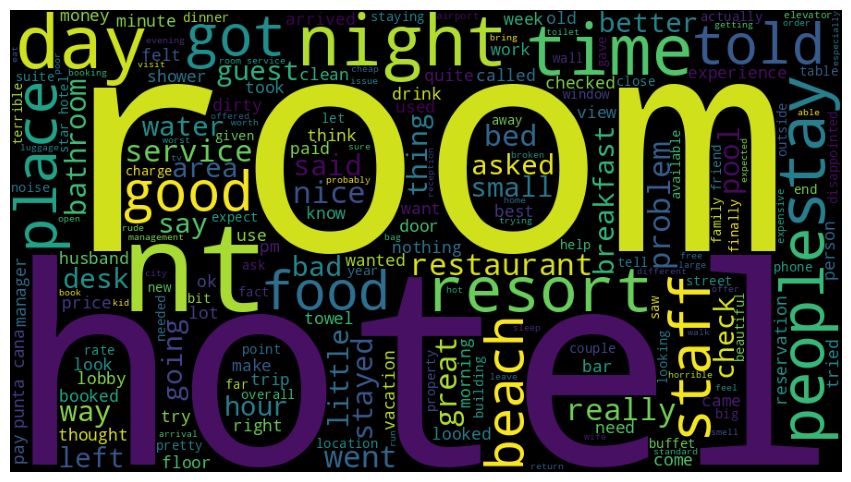

In [21]:
negative_text = " ".join(df[df["Sentiment"]=="Negative"]["Clean_Review"])

wc = WordCloud(
    width=900,
    height=500,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.show()

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=20)

X = cv.fit_transform(df["Clean_Review"])

words = cv.get_feature_names_out()

counts = X.toarray().sum(axis=0)

freq = pd.DataFrame({

    "Word":words,
    "Count":counts

})

freq = freq.sort_values("Count",ascending=False)

print(freq)

          Word  Count
7        hotel  52956
14        room  46378
6        great  21098
11          nt  19007
5         good  17054
16       staff  16280
17        stay  15341
10       night  14085
3          day  12961
19        time  12611
9         nice  12412
8     location  11236
15     service  10538
18      stayed  10469
13  restaurant  10092
0        beach  10047
1    breakfast   9655
12       place   9381
2        clean   9373
4         food   9259


In [23]:
positive = len(df[df["Sentiment"]=="Positive"])

neutral = len(df[df["Sentiment"]=="Neutral"])

negative = len(df[df["Sentiment"]=="Negative"])

total = len(df)

report = pd.DataFrame({

    "Total Reviews":[total],

    "Positive Reviews":[positive],

    "Neutral Reviews":[neutral],

    "Negative Reviews":[negative],

    "Customer Satisfaction (%)":[round((positive/total)*100,2)]

})

print(report)

   Total Reviews  Positive Reviews  Neutral Reviews  Negative Reviews  \
0          20491             15093             2184              3214   

   Customer Satisfaction (%)  
0                      73.66  


In [24]:
report.to_csv("customer_satisfaction_report.csv",index=False)

In [25]:
df.to_csv("hotel_review_analysis_output.csv",index=False)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

X = df["Clean_Review"]

y = df["Sentiment"]

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

Accuracy : 0.8616735789216882
              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78       625
     Neutral       0.53      0.20      0.29       432
    Positive       0.89      0.98      0.93      3042

    accuracy                           0.86      4099
   macro avg       0.74      0.65      0.67      4099
weighted avg       0.84      0.86      0.84      4099

